# Exploración de tablas y visualizaciones básicas — `fraude_pagos`

Herramienta Antifraude para la Detección de Anomalías en Transacciones Comerciales — prácticas de empresa.

Este notebook cubre el EDA (*exploratory data analysis*) del dataset ya cargado en ClickHouse: volumen por tabla, distribuciones de las variables clave (transacciones por cliente, montos, merchants, devices, tarjetas) y una primera comparativa fraude vs. no fraude. No se hace limpieza ni preprocesado todavía (eso es la parte de mi compañera) — el objetivo aquí es simplemente entender la forma que tienen los datos.

**Índice**
1. Resumen general — filas por tabla
2. `transaccion` — montos, estado, serie temporal, transacciones por cliente
3. `cliente` — antigüedad, métodos de pago y dispositivos por cliente
4. `dispositivo` — devices
5. `sesion` — VPN/proxy, intentos de login, países
6. `metodo_pago` — tarjetas
7. `comercio` / `canal_pago` — merchants
8. `alerta` / `patron` — reparto del fraude generado
9. `devolucion` — reembolsos normales vs. fraudulentos
10. `Fraude vs. no fraude`



## 0. Conexión y configuración

In [50]:
import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

HOST, PORT, USER, PASSWORD, DATABASE = "localhost", 8123, "default", "password", "fraude_pagos"

client = clickhouse_connect.get_client(
    host=HOST, port=PORT, username=USER, password=PASSWORD, database=DATABASE
)
print(f"Conectado a la base de datos \"{DATABASE}\"")


Conectado a la base de datos "fraude_pagos"


## 1. Resumen general — filas por tabla

Una primera foto del volumen de cada tabla. Sirve para detectar de un vistazo si algo se ha disparado o si alguna tabla se ha quedado vacía por error.

In [51]:
TABLAS = ["cliente", "comercio", "dispositivo", "patron", "metodo_pago", "canal_pago",
          "cliente_dispositivo", "sesion", "evento", "transaccion", "devolucion", "alerta"]

resumen = pd.DataFrame({
    "tabla": TABLAS,
    "filas": [client.command(f"SELECT count() FROM {t}") for t in TABLAS],
}).sort_values("filas", ascending=False)

resumen


,tabla,filas
8,evento,74073
9,transaccion,36891
7,sesion,36626
4,metodo_pago,4008
6,cliente_dispositivo,3068
2,dispositivo,2600
0,cliente,2000
11,alerta,724
10,devolucion,152
5,canal_pago,44


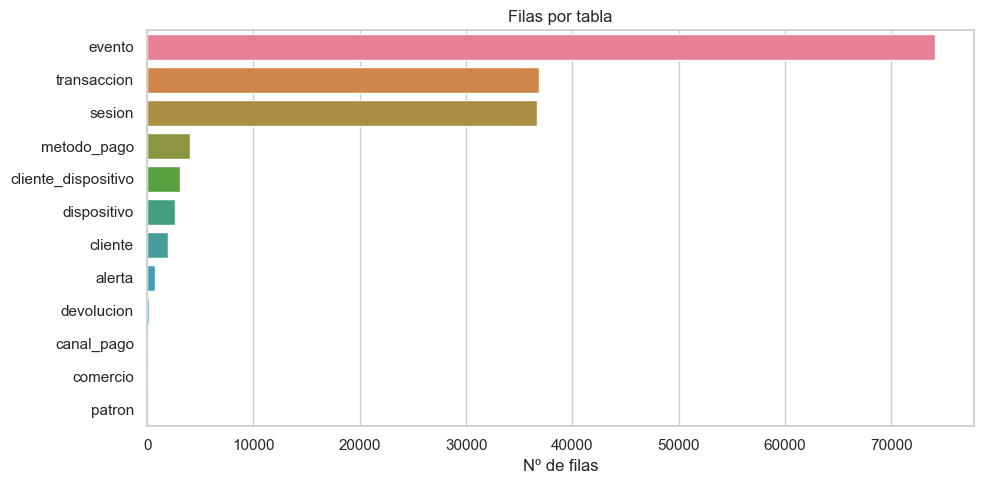

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=resumen, x="filas", y="tabla", hue="tabla", legend=False, ax=ax)
ax.set_title("Filas por tabla")
ax.set_xlabel("Nº de filas")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 2. `transaccion` — el núcleo del dataset

### 2.1 Distribución de importes (montos)

El gráfico de la izquierda está acotado a un rango fijo (0-6.000€) para que se vea bien la segmentación de la mayoría de transacciones (los importes muy altos son en su mayoría fraude — `pico_gasto`, `bust_out` — y ya se ven completos en el gráfico logarítmico de la derecha, que cubre todo el rango).

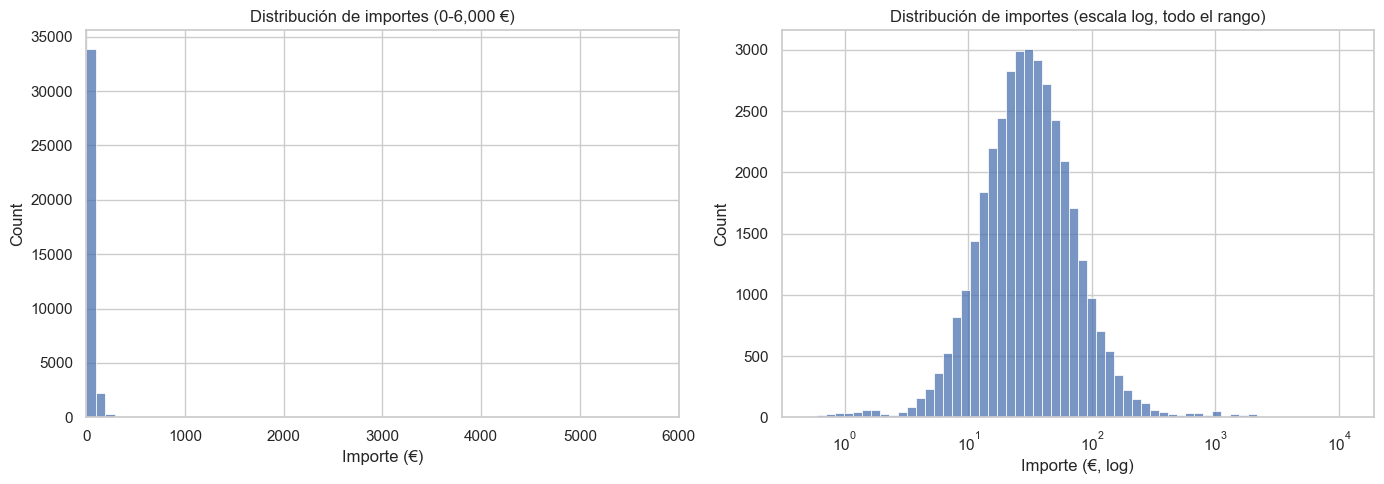

Máximo real: 11,612.33 € 


In [64]:
df_txn = client.query_df("SELECT transaccion_id, metodo_id, cantidad, estado, tipo_operacion, es_fraude, timestamp FROM transaccion")

CUTOFF = 6000  # límite fijo del eje horizontal en el gráfico de la izquierda (en €)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_txn.loc[df_txn["cantidad"] <= CUTOFF, "cantidad"], bins=60, ax=axes[0])
axes[0].set_xlim(0, CUTOFF)
axes[0].set_title(f"Distribución de importes (0-{CUTOFF:,.0f} €)")
axes[0].set_xlabel("Importe (€)")

sns.histplot(df_txn["cantidad"], bins=60, log_scale=True, ax=axes[1])
axes[1].set_title("Distribución de importes (escala log, todo el rango)")
axes[1].set_xlabel("Importe (€, log)")
plt.tight_layout()
plt.show()

n_por_encima = (df_txn["cantidad"] > CUTOFF).sum()
print(f"Máximo real: {df_txn['cantidad'].max():,.2f} € ")


### 2.2 Estado y tipo de operación


estado
aprobada     95.52
rechazada     4.48
Name: proportion, dtype: Float64

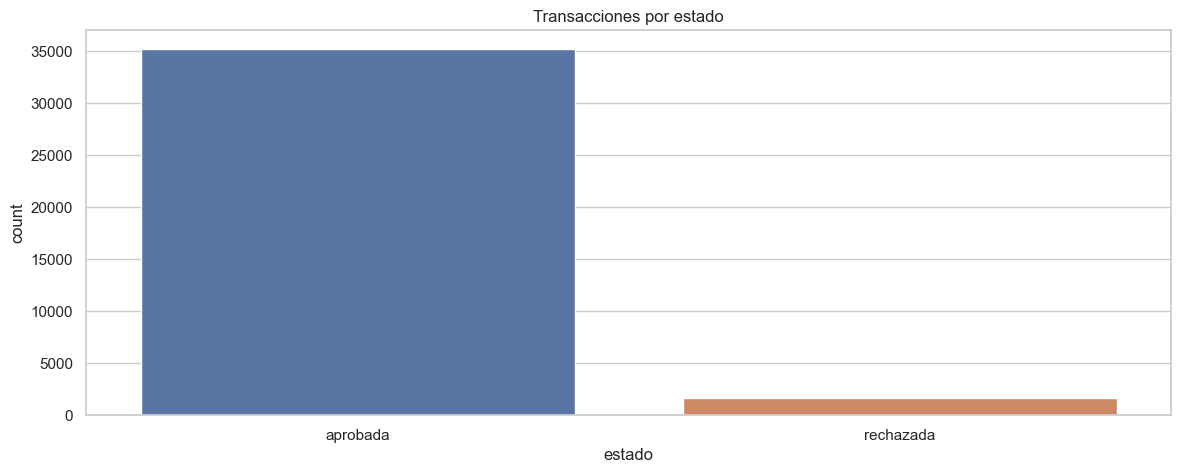

In [65]:
fig, axes = plt.subplots(figsize=(14, 5))
sns.countplot(data=df_txn, x="estado", hue="estado", legend=False)
axes.set_title("Transacciones por estado")


df_txn["estado"].value_counts(normalize=True).mul(100).round(2)


### 2.3 Serie temporal — transacciones por día


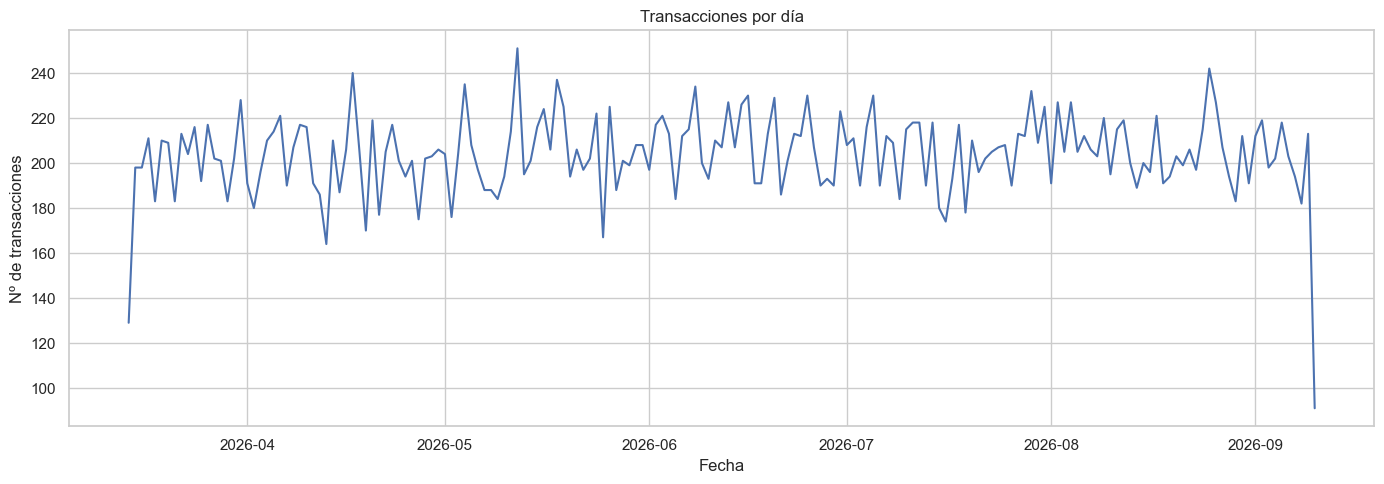

Media diaria: 203.8  |  mínimo: 91  |  máximo: 251


In [58]:
df_txn["fecha"] = pd.to_datetime(df_txn["timestamp"]).dt.date
por_dia = df_txn.groupby("fecha").size()

fig, ax = plt.subplots(figsize=(14, 5))
por_dia.plot(ax=ax)
ax.set_title("Transacciones por día")
ax.set_xlabel("Fecha")
ax.set_ylabel("Nº de transacciones")
plt.tight_layout()
plt.show()

print(f"Media diaria: {por_dia.mean():.1f}  |  mínimo: {por_dia.min()}  |  máximo: {por_dia.max()}")


### 2.4 Transacciones por cliente

`transaccion` no tiene `cliente_id` directo — se llega a través de `metodo_pago`, tal y como se diseñó el esquema normalizado (Cliente no está directamente enlazado a Transacción). Refleja cuántas transacciones e importe total genera cada cliente en los 6 meses: la mayoría deberían tener un volumen moderado y parecido entre sí, con alguna cola de clientes muy activos o con importes altos (candidatos a revisar junto con las alertas).

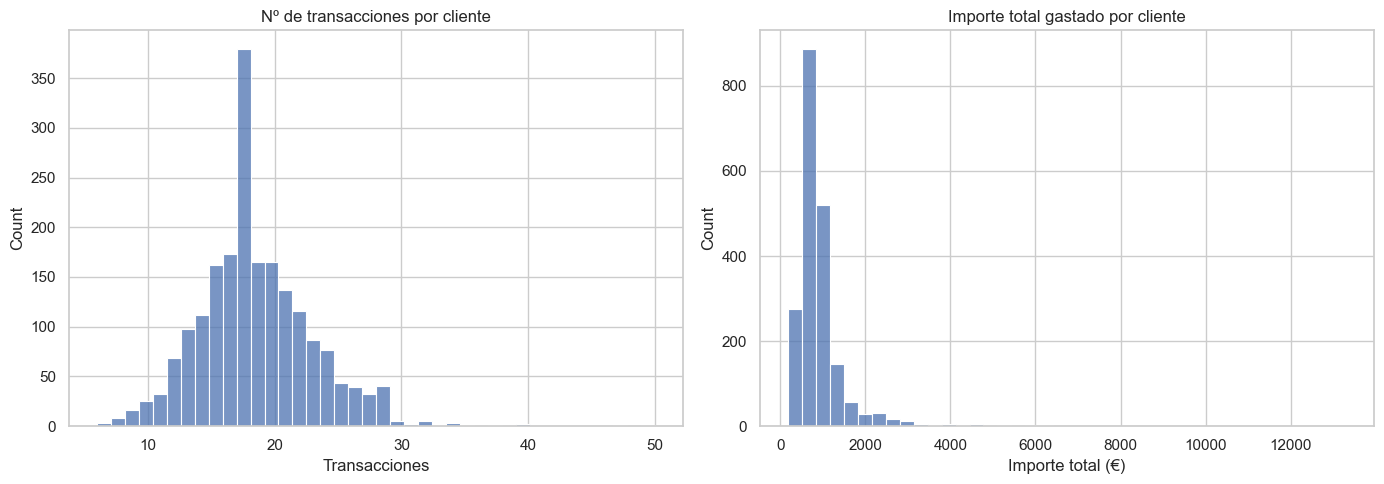

,n_transacciones
count,2000.000000
mean,18.445500
std,4.527723
min,6.000000
25%,15.000000
50%,18.000000
75%,21.000000
max,50.000000


In [62]:
txn_por_cliente = client.query_df("""
    SELECT m.cliente_id, count() AS n_transacciones, round(sum(t.cantidad), 2) AS importe_total
    FROM transaccion t
    JOIN metodo_pago m ON t.metodo_id = m.metodo_id
    GROUP BY m.cliente_id
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(txn_por_cliente["n_transacciones"], bins=40, ax=axes[0])
axes[0].set_title("Nº de transacciones por cliente")
axes[0].set_xlabel("Transacciones")

sns.histplot(txn_por_cliente["importe_total"], bins=40, ax=axes[1])
axes[1].set_title("Importe total gastado por cliente")
axes[1].set_xlabel("Importe total (€)")
plt.tight_layout()
plt.show()

txn_por_cliente[["n_transacciones", "importe_total"]].describe()


## 3. Cliente — antigüedad y actividad

### 3.1 Antigüedad de los clientes

`cliente.timestamp` es la fecha de alta (hasta 700 días antes del inicio del dataset). Refleja cuántos días de antigüedad tienen a fecha de hoy.

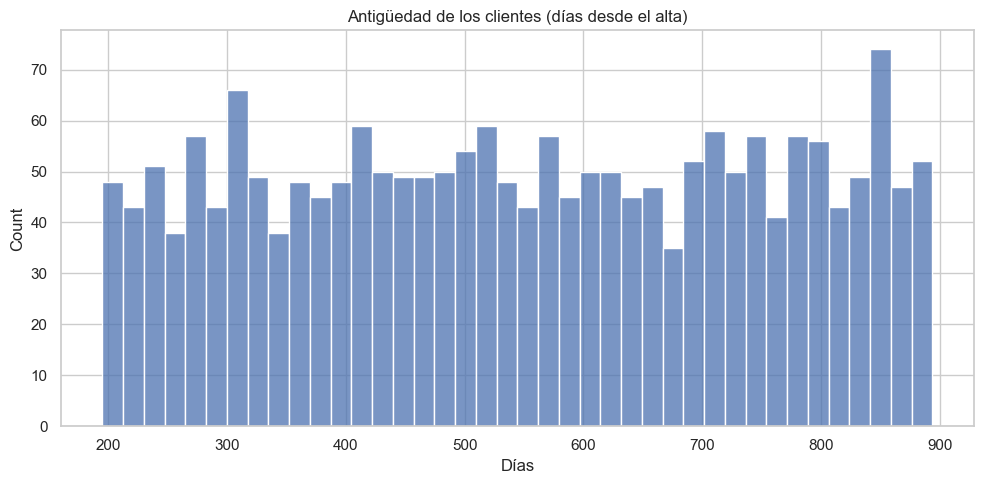

In [63]:
df_cli = client.query_df("SELECT cliente_id, timestamp FROM cliente")
df_cli["antiguedad_dias"] = (pd.Timestamp.now() - pd.to_datetime(df_cli["timestamp"])).dt.days

fig, ax = plt.subplots()
sns.histplot(df_cli["antiguedad_dias"], bins=40, ax=ax)
ax.set_title("Antigüedad de los clientes (días desde el alta)")
ax.set_xlabel("Días")
plt.tight_layout()
plt.show()


### 3.2 Métodos de pago y dispositivos por cliente

Cuántos métodos de pago y dispositivos personales tiene cada cliente en promedio.

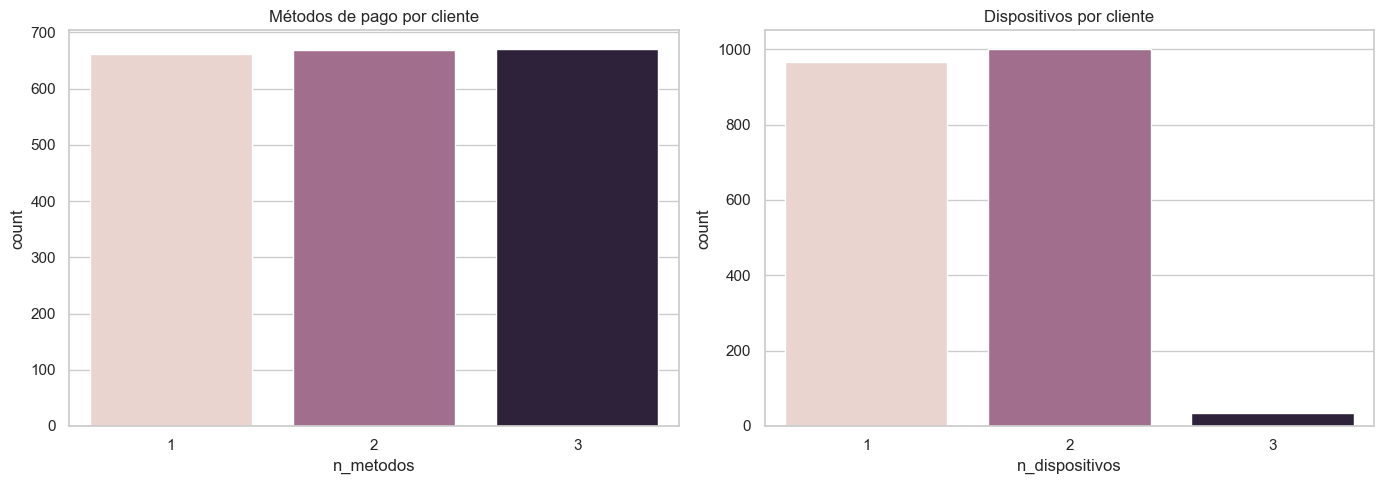

In [66]:
metodos_por_cliente = client.query_df(
    "SELECT cliente_id, count() AS n_metodos FROM metodo_pago GROUP BY cliente_id"
)
disp_por_cliente = client.query_df(
    "SELECT cliente_id, count() AS n_dispositivos FROM cliente_dispositivo GROUP BY cliente_id"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=metodos_por_cliente, x="n_metodos", hue="n_metodos", legend=False, ax=axes[0])
axes[0].set_title("Métodos de pago por cliente")

sns.countplot(data=disp_por_cliente, x="n_dispositivos", hue="n_dispositivos", legend=False, ax=axes[1])
axes[1].set_title("Dispositivos por cliente")
plt.tight_layout()
plt.show()


## 4. `dispositivo` — devices

Distribución de las compras según el tipo de dispositivo y sistema operativo

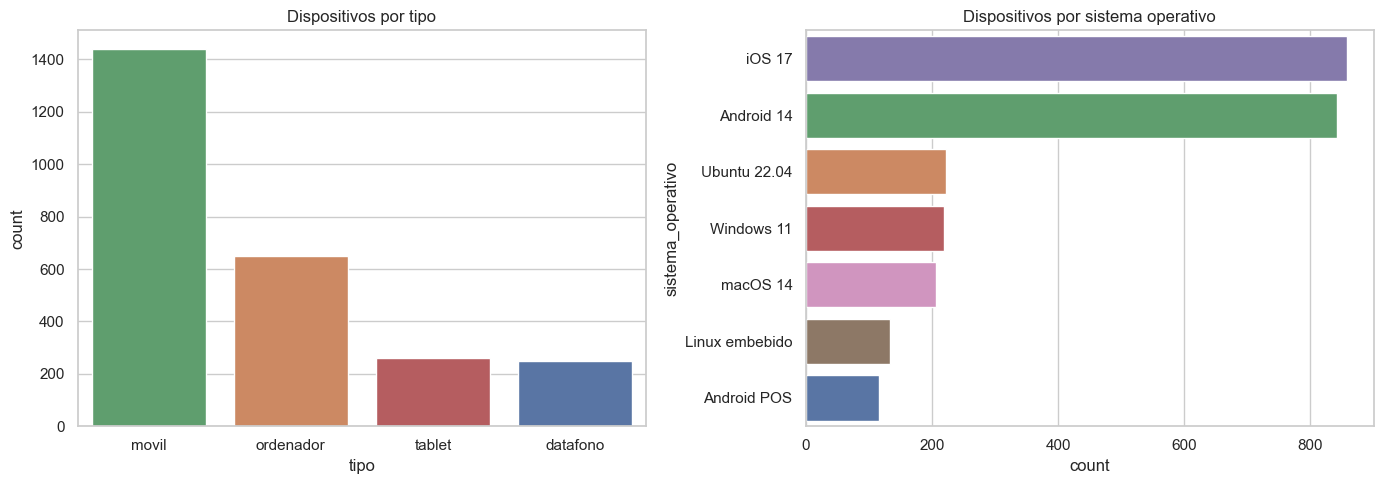

tipo
movil        55.3
ordenador    25.0
tablet       10.1
datafono      9.6
Name: proportion, dtype: Float64

In [67]:
df_disp = client.query_df("SELECT dispositivo_id, tipo, sistema_operativo FROM dispositivo")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_disp, x="tipo", hue="tipo", legend=False,
              order=df_disp["tipo"].value_counts().index, ax=axes[0])
axes[0].set_title("Dispositivos por tipo")

sns.countplot(data=df_disp, y="sistema_operativo", hue="sistema_operativo", legend=False,
              order=df_disp["sistema_operativo"].value_counts().index, ax=axes[1])
axes[1].set_title("Dispositivos por sistema operativo")
plt.tight_layout()
plt.show()

df_disp["tipo"].value_counts(normalize=True).mul(100).round(1)


## 5. `sesion` — señales de riesgo a nivel de sesión

### 5.1 VPN/proxy e intentos de login

En la mayoría de sesiones normales `proxy_vpn` debería ser falso y `num_intentos_login` = 1; los valores altos vienen casi todos de los casos de `account_takeover` e `ip_sospechosa`.

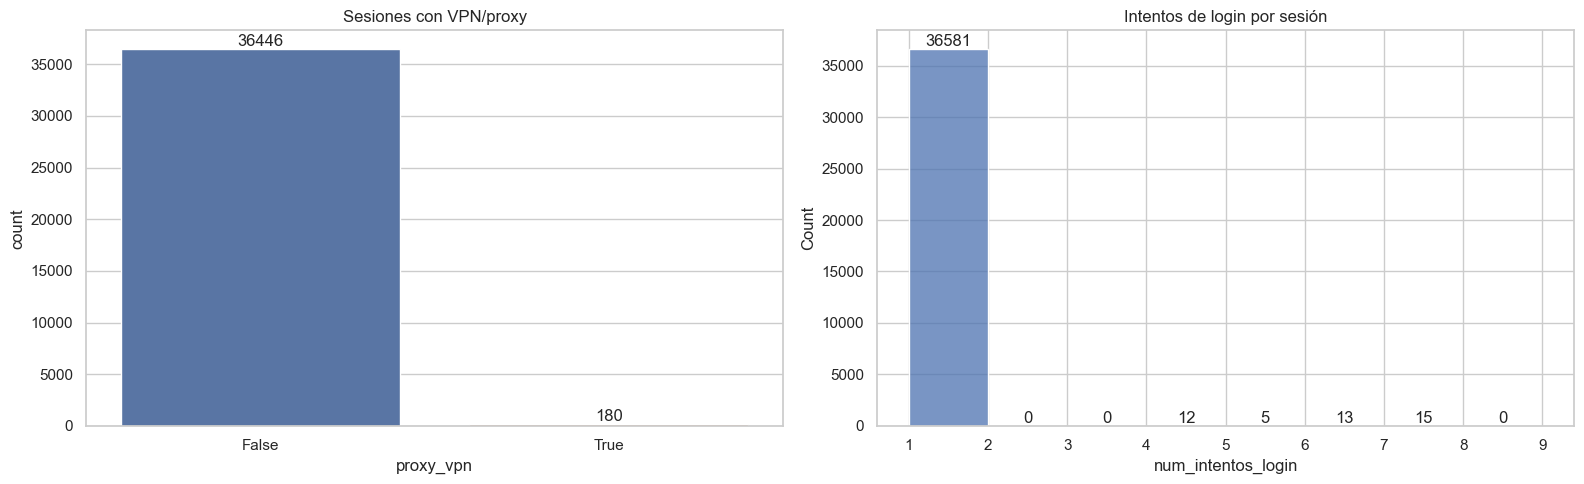

% sesiones con VPN/proxy: 0.49%


In [82]:
df_ses = client.query_df("SELECT sesion_id, ip_pais, proxy_vpn, num_intentos_login, resultado_login FROM sesion")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df_ses, x="proxy_vpn", hue="proxy_vpn", legend=False, ax=axes[0])
axes[0].set_title("Sesiones con VPN/proxy")
for cont in axes[0].containers:
    axes[0].bar_label(cont)

sns.histplot(df_ses["num_intentos_login"], bins=range(1, 10), ax=axes[1])
axes[1].set_title("Intentos de login por sesión")
for cont in axes[1].containers:
    axes[1].bar_label(cont)

plt.tight_layout()
plt.show()

print(f"% sesiones con VPN/proxy: {df_ses['proxy_vpn'].mean() * 100:.2f}%")


### 5.2 Países más frecuentes en `ip_pais`


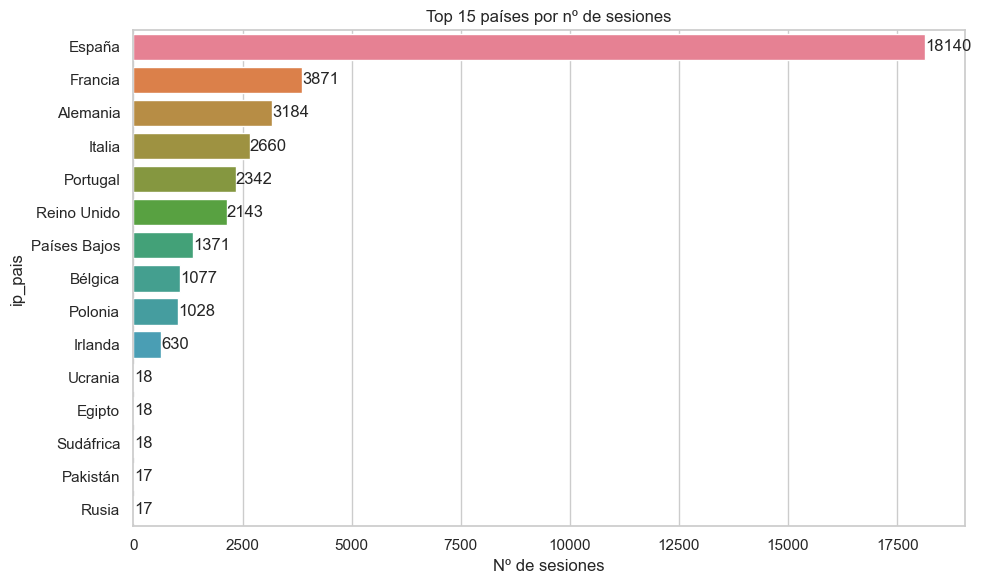

In [83]:
top_paises = df_ses["ip_pais"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, legend=False, ax=ax)
ax.set_title("Top 15 países por nº de sesiones")
ax.set_xlabel("Nº de sesiones")
for cont in ax.containers:
    ax.bar_label(cont)
plt.tight_layout()
plt.show()


## 6. `metodo_pago` — tarjetas

### 6.1 Tipo y entidad emisora

Reparto de tarjetas entre crédito/débito y por entidad emisora.

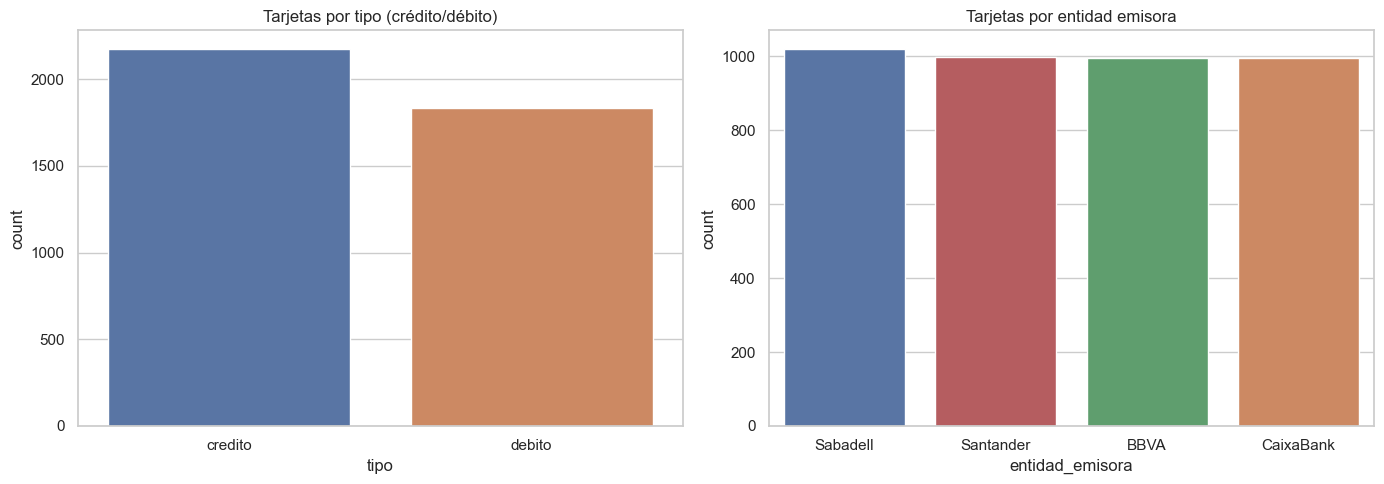

In [73]:
df_metodo = client.query_df("SELECT metodo_id, cliente_id, tipo, entidad_emisora, limite_credito, estado FROM metodo_pago")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_metodo, x="tipo", hue="tipo", legend=False, ax=axes[0])
axes[0].set_title("Tarjetas por tipo (crédito/débito)")

sns.countplot(data=df_metodo, x="entidad_emisora", hue="entidad_emisora", legend=False,
              order=df_metodo["entidad_emisora"].value_counts().index, ax=axes[1])
axes[1].set_title("Tarjetas por entidad emisora")
plt.tight_layout()
plt.show()


### 6.2 Límite de crédito

Solo aplica a tarjetas de tipo `credito` (en débito `limite_credito` es nulo). Este límite es justo el valor contra el que se compara el importe final en los casos de `bust_out` (85-98% del límite).

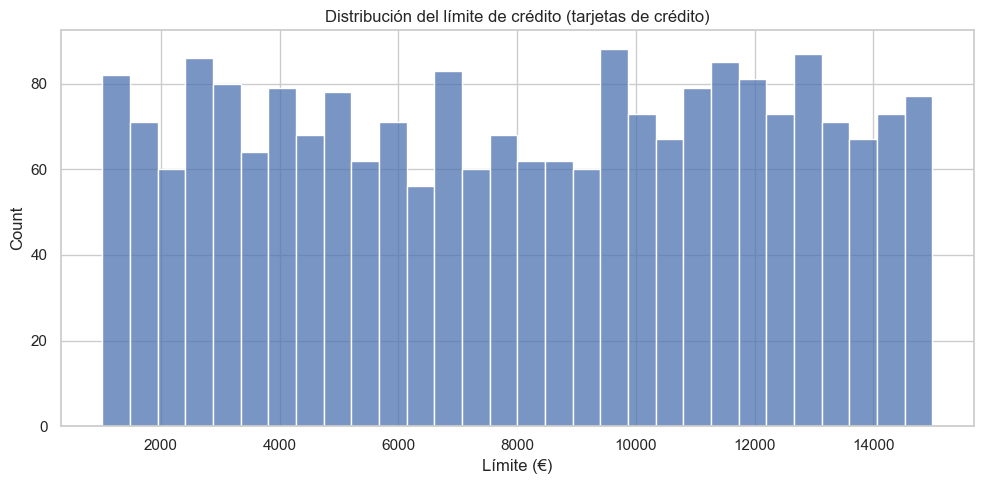

count         2173
unique        2015
top       11651.00
freq             4
Name: limite_credito, dtype: object

In [74]:
creditos = df_metodo[df_metodo["tipo"] == "credito"]

fig, ax = plt.subplots()
sns.histplot(creditos["limite_credito"], bins=30, ax=ax)
ax.set_title("Distribución del límite de crédito (tarjetas de crédito)")
ax.set_xlabel("Límite (€)")
plt.tight_layout()
plt.show()

creditos["limite_credito"].describe()


## 7. `comercio` y `canal_pago` 

### 7.1 Comercios por categoría de negocio y canales por tipo

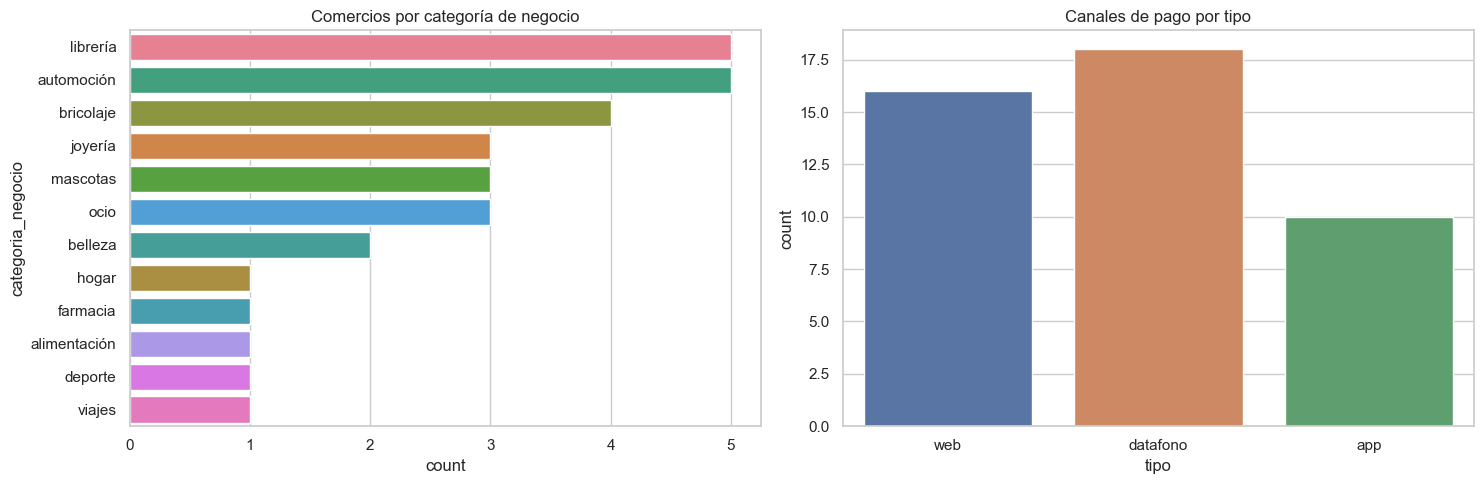

In [75]:
df_com = client.query_df("SELECT comercio_id, categoria_negocio, pais FROM comercio")
df_can = client.query_df("SELECT canal_id, comercio_id, tipo FROM canal_pago")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df_com, y="categoria_negocio", hue="categoria_negocio", legend=False,
              order=df_com["categoria_negocio"].value_counts().index, ax=axes[0])
axes[0].set_title("Comercios por categoría de negocio")

sns.countplot(data=df_can, x="tipo", hue="tipo", legend=False, ax=axes[1])
axes[1].set_title("Canales de pago por tipo")
plt.tight_layout()
plt.show()


### 7.2 Comercios por país

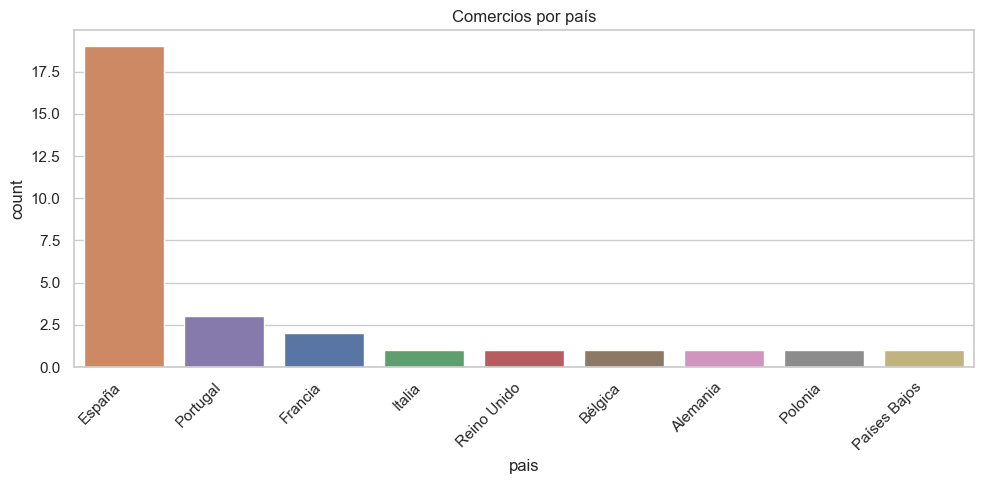

In [76]:
fig, ax = plt.subplots()
sns.countplot(data=df_com, x="pais", hue="pais", legend=False,
              order=df_com["pais"].value_counts().index, ax=ax)
ax.set_title("Comercios por país")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 7.3 Top comercios por transacciones e importe

A nivel de categoría ya vimos el reparto general; aquí bajamos a comercio individual, que es lo relevante para detectar concentraciones anómalas de actividad en un merchant concreto.

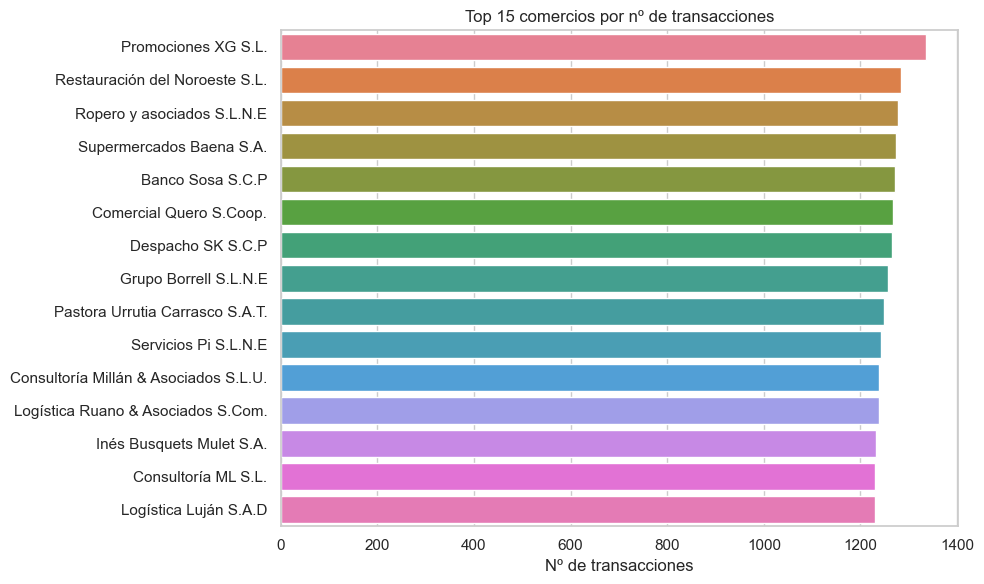

,comercio,categoria_negocio,n_transacciones,importe_total
0,Promociones XG S.L.,automoción,1335,63467.72
1,Restauración del Noroeste S.L.,ocio,1283,63838.86
2,Ropero y asociados S.L.N.E,belleza,1278,59054.05
3,Supermercados Baena S.A.,deporte,1273,76032.17
4,Banco Sosa S.C.P,viajes,1271,64570.66
5,Comercial Quero S.Coop.,automoción,1267,61912.44
6,Despacho SK S.C.P,librería,1265,62209.33
7,Grupo Borrell S.L.N.E,librería,1256,72516.15
8,Pastora Urrutia Carrasco S.A.T.,belleza,1248,62166.21
9,Servicios Pi S.L.N.E,mascotas,1243,56880.26


In [77]:
top_comercios = client.query_df("""
    SELECT c.nombre AS comercio, c.categoria_negocio, count() AS n_transacciones,
           round(sum(t.cantidad), 2) AS importe_total
    FROM transaccion t
    JOIN canal_pago cp ON t.canal_id = cp.canal_id
    JOIN comercio c ON cp.comercio_id = c.comercio_id
    GROUP BY c.nombre, c.categoria_negocio
    ORDER BY n_transacciones DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_comercios, x="n_transacciones", y="comercio", hue="comercio", legend=False, ax=ax)
ax.set_title("Top 15 comercios por nº de transacciones")
ax.set_xlabel("Nº de transacciones")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

top_comercios


## 8. `alerta` y `patron` — reparto del fraude generado

### 8.1 Nº de alertas por tipo de patrón


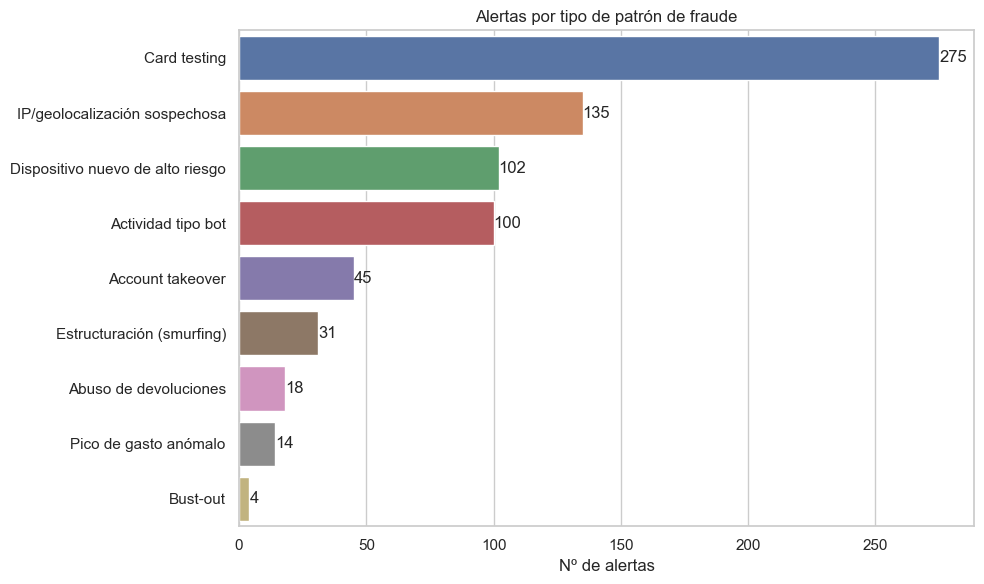

,patron,n_alertas,pct_del_fraude
0,Card testing,275,38.0
1,IP/geolocalización sospechosa,135,18.6
2,Dispositivo nuevo de alto riesgo,102,14.1
3,Actividad tipo bot,100,13.8
4,Account takeover,45,6.2
5,Estructuración (smurfing),31,4.3
6,Abuso de devoluciones,18,2.5
7,Pico de gasto anómalo,14,1.9
8,Bust-out,4,0.6


In [84]:
alertas_por_patron = client.query_df("""
    SELECT p.nombre AS patron, count() AS n_alertas,
           round(count() * 100.0 / (SELECT count() FROM alerta), 1) AS pct_del_fraude
    FROM alerta a
    JOIN patron p ON a.patron_id = p.patron_id
    GROUP BY p.nombre
    ORDER BY n_alertas DESC
""")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=alertas_por_patron, x="n_alertas", y="patron", hue="patron", legend=False, ax=ax)
ax.set_title("Alertas por tipo de patrón de fraude")
ax.set_xlabel("Nº de alertas")
ax.set_ylabel("")
for cont in ax.containers:
    ax.bar_label(cont)
plt.tight_layout()
plt.show()

alertas_por_patron


### 8.2 Distribución de `nota_riesgo`

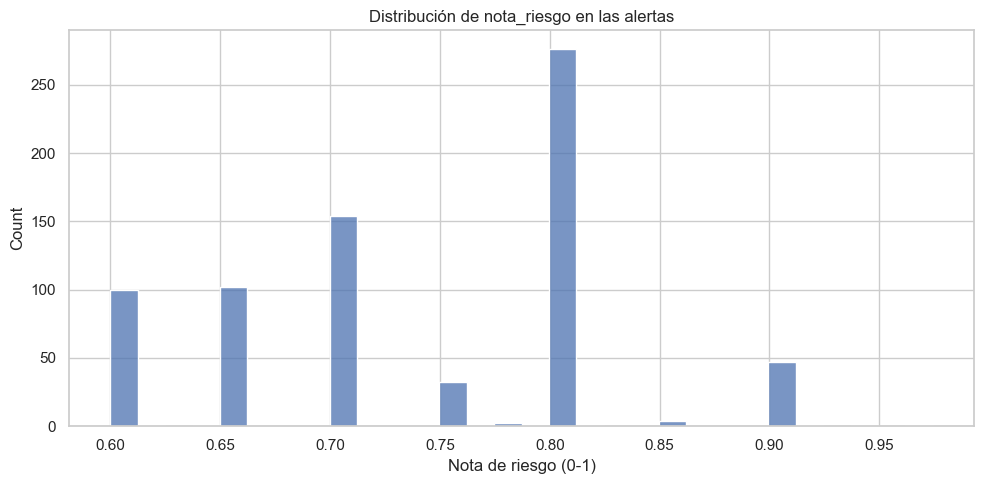

In [79]:
df_alerta = client.query_df("SELECT nota_riesgo FROM alerta")

fig, ax = plt.subplots()
sns.histplot(df_alerta["nota_riesgo"], bins=30, ax=ax)
ax.set_title("Distribución de nota_riesgo en las alertas")
ax.set_xlabel("Nota de riesgo (0-1)")
plt.tight_layout()
plt.show()


## 9. `devolucion` — reembolsos normales vs. fraudulentos

`tipo` distingue `reembolso_total` (devoluciones normales) de `fraudulenta` (ligadas al patrón de abuso de devoluciones).

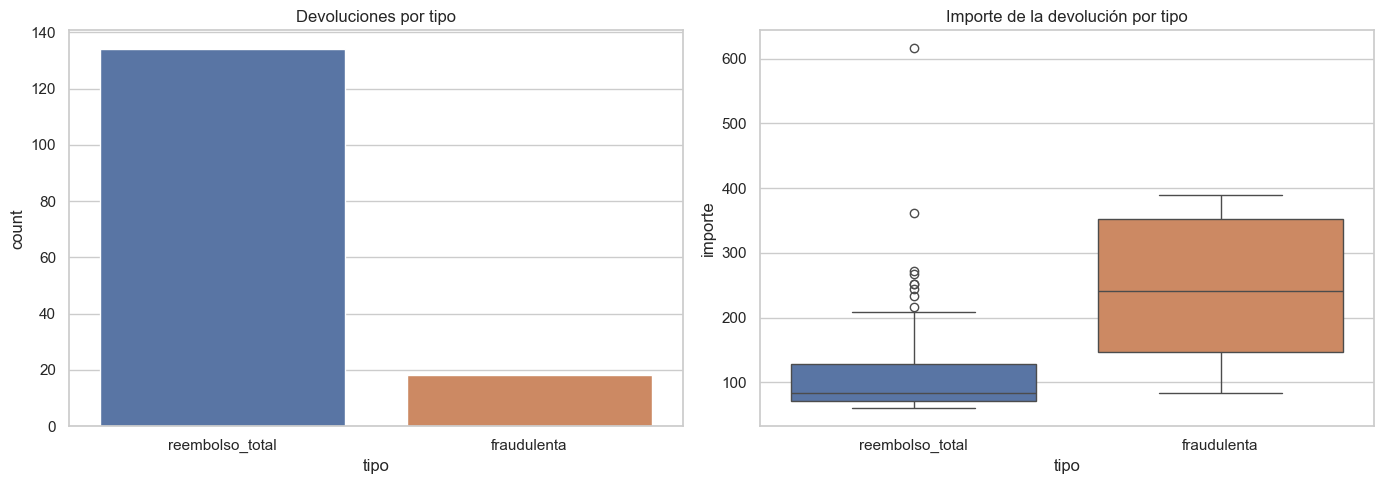

Devoluciones por tipo:
tipo
reembolso_total    134
fraudulenta         18

Importe por tipo (n, mediana, media):
                   n  mediana   media
tipo                                 
fraudulenta       18   241.13  244.16
reembolso_total  134    84.18  110.23


In [88]:
df_devol = client.query_df("SELECT tipo, importe FROM devolucion")
df_devol["importe"] = df_devol["importe"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_devol, x="tipo", hue="tipo", legend=False, ax=axes[0])
axes[0].set_title("Devoluciones por tipo")

sns.boxplot(data=df_devol, x="tipo", y="importe", hue="tipo", legend=False, ax=axes[1])
axes[1].set_title("Importe de la devolución por tipo")

plt.tight_layout()
plt.show()

print("Devoluciones por tipo:")
print(df_devol["tipo"].value_counts().to_string())

print("\nImporte por tipo (n, mediana, media):")
resumen_devol = df_devol.groupby("tipo")["importe"].agg(n="count", mediana="median", media="mean").round(2)
print(resumen_devol.to_string())

Las devoluciones fraudulentas tienen una mediana de importe bastante más alta que las de reembolso normal, y su caja es más ancha, es decir, más dispersión de importes. Las reembolso_total, en cambio, se concentran en importes bajos pero tienen varios outliers hasta ~600€ — probablemente devoluciones de compras puntuales de importe alto. Ninguna devolución fraudulenta destaca como outlier extremo.

## 10. Fraude vs. no fraude — primera comparativa

Aquí se compara las transacciones marcadas como fraude (`es_fraude=1`) frente al resto, mirando dos cosas: cuántas hay de cada clase, y cómo se distribuye el importe en cada una. Si ya se ve una diferencia clara en el importe entre fraude y normal, es una buena señal de que esa variable va a ayudar a los modelos de detección más adelante.

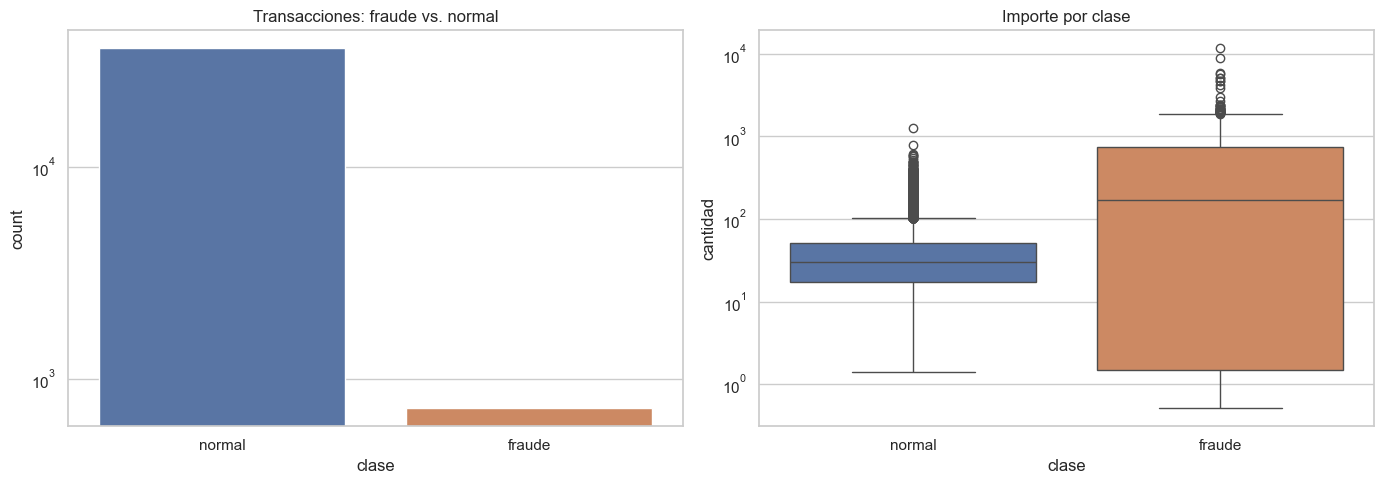

Transacciones por clase:
clase
normal    36167
fraude      724

Importe por clase (n, mediana, media):
            n  mediana   media
clase                         
fraude    724   168.64  515.97
normal  36167    29.98   41.50


In [91]:
df_comparativa = client.query_df("""
    SELECT transaccion_id, cantidad,
           if(es_fraude = 1, 'fraude', 'normal') AS clase
    FROM transaccion
""")
df_comparativa["cantidad"] = df_comparativa["cantidad"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df_comparativa, x="clase", hue="clase", legend=False, ax=axes[0])
axes[0].set_title("Transacciones: fraude vs. normal")
axes[0].set_yscale("log")

sns.boxplot(data=df_comparativa, x="clase", y="cantidad", hue="clase", legend=False, ax=axes[1])
axes[1].set_title("Importe por clase")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print("Transacciones por clase:")
print(df_comparativa["clase"].value_counts().to_string())

print("\nImporte por clase (n, mediana, media):")
resumen_comparativa = df_comparativa.groupby("clase")["cantidad"].agg(n="count", mediana="median", media="mean").round(2)
print(resumen_comparativa.to_string())

El grupo de fraude tiene muchas menos transacciones que el normal, pero su importe medio y mediana son bastante más altos y con más dispersión. Tiene sentido: patrones como `pico_gasto` o `bust_out` generan importes de miles de euros a propósito, mientras que la mayoría de transacciones normales son de importe bajo. Esa diferencia de importe entre clases es justo la señal que un modelo no supervisado puede aprovechar para separarlas.